In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os, subprocess
import bioframe
from sample import *
from supp_lib import *
import seaborn as sns
import cooltools

In [20]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
info = pd.read_csv("cooltools54/Sample_info.tsv",sep='\t')
info.head()

,Sample,PC,Color
0,OU-HiC-C2-pfib-D16,Patient,D16
1,OU-HiC-C2-pfib-D4,Patient,D4
2,OU-HiC-C3-pfib-D16,Patient,D16
3,OU-HiC-C3-pfib-D4,Patient,D4
4,OU-HiC-N6-pfib-D16,Control,D16


In [12]:
stn = pd.DataFrame(columns=['Sample','A','B'])
print(stn.head())
for i,f in enumerate(indi+grps):
    with np.load('cooltools54/SaddleCis-arms/April-2024/Saddle-Cis-Arms-100kbs/'+f+'.saddledump.npz') as data:
        x = data['saddle_strength-A']
        y = data['saddle_strength-B']
    A=np.around(x[int(np.floor(0.2*len(x)))],2)
    B=np.around(y[int(np.floor(0.2*len(y)))],2)
    stn.loc[i] = [f,A,B]

Empty DataFrame
Columns: [Sample, A, B]
Index: []


In [13]:
#stn = pd.read_csv("Strengths-cis-arms-1Mb.tsv",sep='\t')
stn.head()

,Sample,A,B
0,OU-HiC-C2-pfib-D16,3.98,6.93
1,OU-HiC-C2-pfib-D4,5.22,9.08
2,OU-HiC-C3-pfib-D16,4.48,7.58
3,OU-HiC-C3-pfib-D4,5.62,9.09
4,OU-HiC-N6-pfib-D16,3.61,6.39


In [15]:
fin = pd.merge(stn,info,on='Sample')
fin.head()
#save in case , want to change PC/Color columns manually
#fin.to_csv("cooltools54/SaddleCis-arms/April-2024/Strengths-cis-arms.tsv",sep='\t',index=False)

,Sample,A,B,PC,Color
0,OU-HiC-C2-pfib-D16,3.98,6.93,Patient,D16
1,OU-HiC-C2-pfib-D4,5.22,9.08,Patient,D4
2,OU-HiC-C3-pfib-D16,4.48,7.58,Patient,D16
3,OU-HiC-C3-pfib-D4,5.62,9.09,Patient,D4
4,OU-HiC-N6-pfib-D16,3.61,6.39,Control,D16


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 43 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'I', 'M', 'N', 'P', 'S', 'T', 'W', 'a', 'b', 'colon', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 36, 37, 38, 39, 40, 41, 44, 48, 49, 51, 54, 55, 58, 68, 69, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87]
INFO:fontTools.subset:Closed glyp

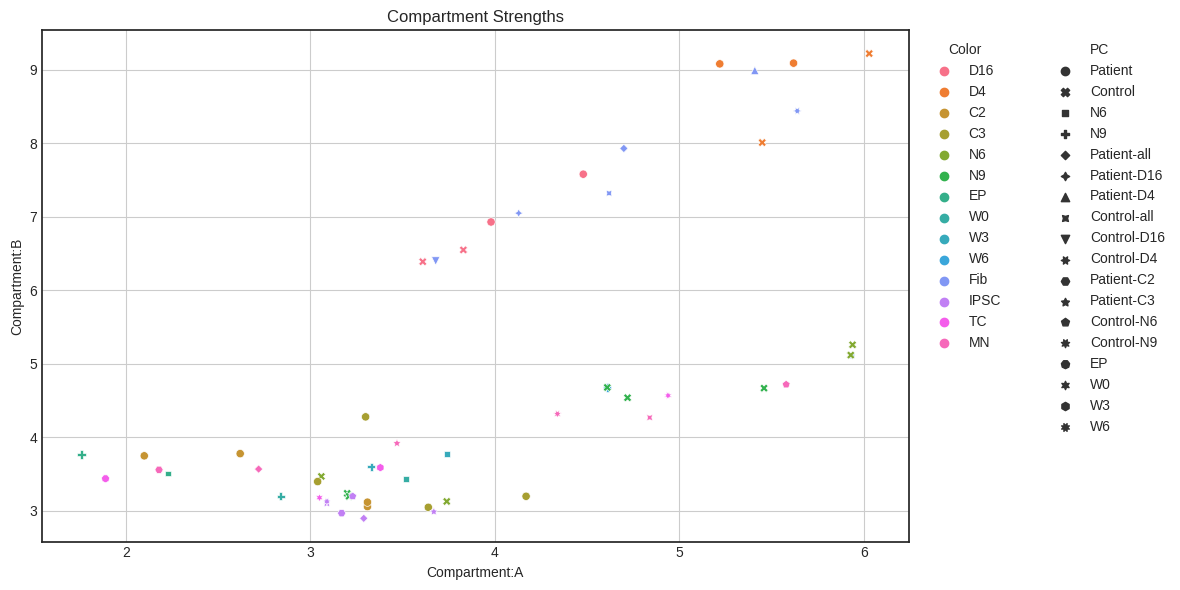

In [33]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.scatterplot(data=fin, x="A", y="B",style='PC',hue='Color')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
#plt.xlim(1.4, 3)
#plt.ylim(1.4, 2.2)

# Get handles and labels for hue and style
hue_handles, hue_labels = ax.get_legend_handles_labels()

# Separate hue and style
# Assumes order: hue entries first, then style
# Adjust slicing if needed
num_colors = fin['Color'].nunique()
num_styles = fin['PC'].nunique()

color_handles = hue_handles[1:1+num_colors]
color_labels = hue_labels[1:1+num_colors]

pc_handles = hue_handles[1+num_colors:]
pc_labels = hue_labels[1+num_colors:]

# Remove default legend
ax.legend_.remove()

# Create two separate legends
legend1 = ax.legend(color_handles, color_labels, title="Color", loc='upper left', bbox_to_anchor=(1.01, 1))
legend2 = ax.legend(pc_handles, pc_labels, loc='upper left', bbox_to_anchor=(1.15, 1))

# Add both legends to the axes
ax.add_artist(legend1)


plt.grid()
plt.xlabel("Compartment:A")
plt.ylabel("Compartment:B")
plt.title("Compartment Strengths")
plt.tight_layout()
plt.savefig("GitHub/Plots/Strength.png",bbox_inches='tight')
plt.savefig("GitHub/Plots/Strength.pdf",bbox_inches='tight')